# High Dimensionality Experiment (p >> n)

Este notebook avalia o cenário de alta dimensionalidade onde o número de preditores supera amplamente o tamanho da amostra (=500 \gg n=100$), com esparsidade estrita (15 variáveis informativas e 485 ruídos).

**Objetivo:** Avaliar a quebra do estimador OLS convencional (matriz de covariância não invertível / sobreajuste extremo) e testar a capacidade dos métodos regularizados (LASSO e Elastic Net) de selecionar preditores relevantes e generalizar bem em espaços de dimensão muito superior a $.


## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Import data generation
from data_generation.generate_data import generate_data

# Import plots
from plots.coefficient_plot import coefficient_plot
from plots.metrics import compute_metrics

# Import models
from models.OLS import run_ols
from models.LASSO import run_lasso, run_lasso_cv
from models.Ridge import run_ridge, run_ridge_cv
from models.ElasticNet import run_elasticnet_alpha, run_elasticnet_l1ratio, run_elasticnet_cv

# Removing Warnings
import warnings


In [2]:
warnings.filterwarnings('ignore')

## 1. Generating Data

GENERATED DATA:
Shape of X: (1000, 1000)

X Matrix: 
 [[-0.11043722  1.30338948 -0.18770552 ... -1.5597464  -0.63303134
  -0.42911909]
 [-0.97239498  0.6750105  -0.37185883 ... -0.73868905 -0.09015542
  -1.4357878 ]
 [ 0.26522909 -1.02928844  1.41652349 ... -1.25287972  1.12997039
  -0.77937333]
 ...
 [-0.31692232 -2.96243593  1.23718698 ... -1.95727067  0.35411076
   0.94763853]
 [-0.6236728   0.51972733 -0.40816521 ...  0.74015168 -1.04286405
   0.40117665]
 [ 1.09223944 -1.07030242  1.08731838 ... -0.55707019  0.49826471
  -0.17660951]]
Shape of y: (1000,)

y Vector: 
 [ 4.29174337e+02 -8.29049594e+02  1.56696848e+03 -1.56648215e+02
 -7.62781515e+01  3.01684060e+02  4.55697645e+02 -2.03856906e+03
 -7.30771225e+02  1.71162654e+03 -1.09275860e+03  8.26746508e+02
 -9.32499989e+01  6.42595872e+01  3.65052397e+02  5.73546804e+02
 -1.01929635e+02  1.77477704e+02 -1.30921267e+03 -2.80568583e+02
  1.90517399e+02  1.09214284e+02 -3.17066514e+02 -5.24315047e+02
 -4.42902536e+02  7.60242965e+0

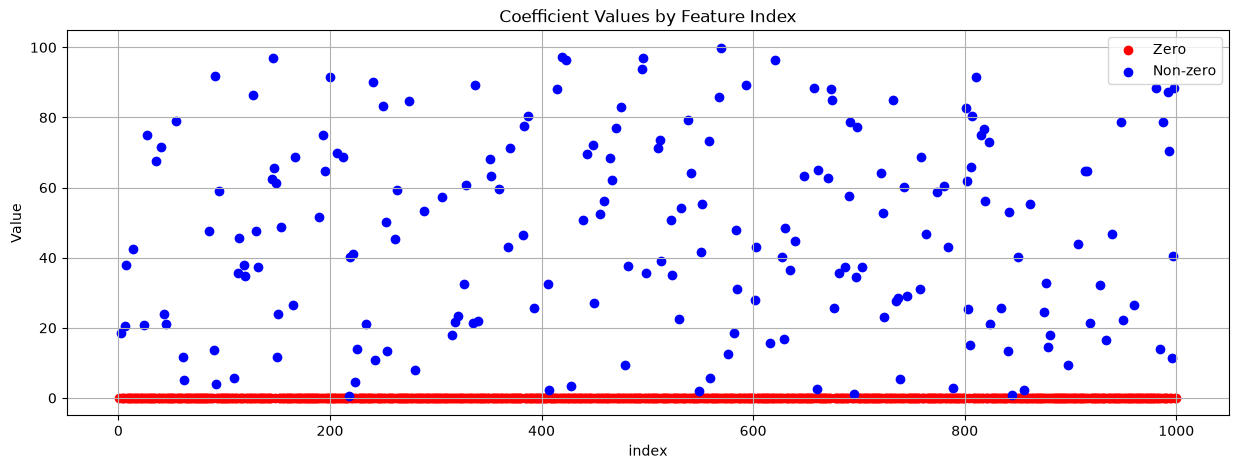

In [ ]:
X_train, X_test, y_train, y_test, coef = generate_data(
    n_samples=100,
    n_features=500,
    n_informative=15,
    noise=1.0,
    effective_rank=None,
    tail_strength=0.5
)

coefficient_plot(coef)


## 2. Ordinary Least Square

MAE: 267.14
MSE: 113063.57
RMSE: 336.25
R² Score: 0.83
Number of non zero coefs: 1000
Max coef magnitude: 101.4789
Mean coef magnitude: 13.7409


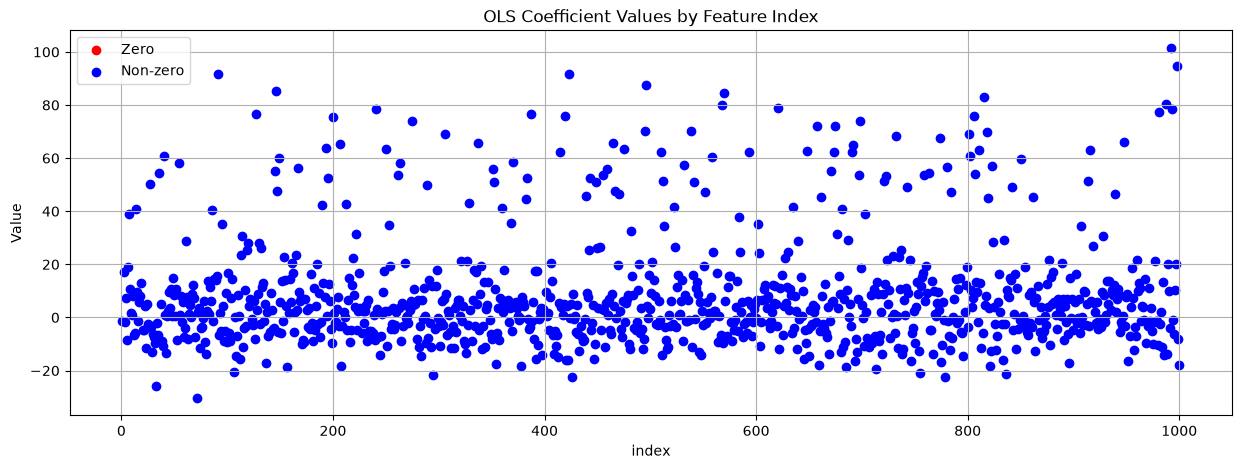

In [4]:
OLS_model = run_ols(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)

## 3. Least Absolute Shrinkage and Selection Operator

Metrics for i = 0.001:
MAE: 320.86
MSE: 160882.21
RMSE: 401.10
R² Score: 0.77
Number of non zero coefs: 1000
Max coef magnitude: 116.2141
Mean coef magnitude: 16.9289


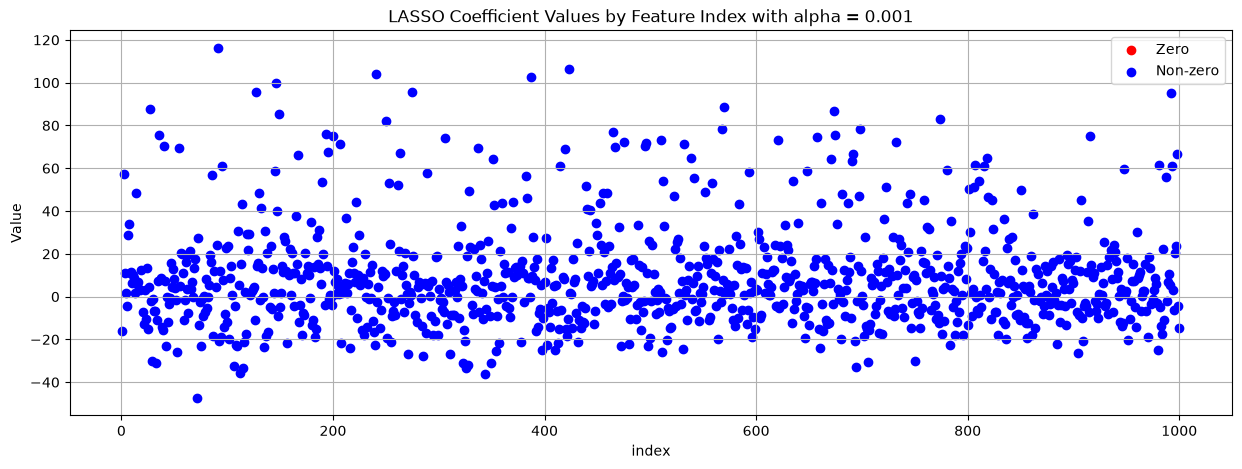

Metrics for i = 0.01:
MAE: 123.82
MSE: 24697.22
RMSE: 157.15
R² Score: 0.96
Number of non zero coefs: 919
Max coef magnitude: 103.4272
Mean coef magnitude: 11.4965


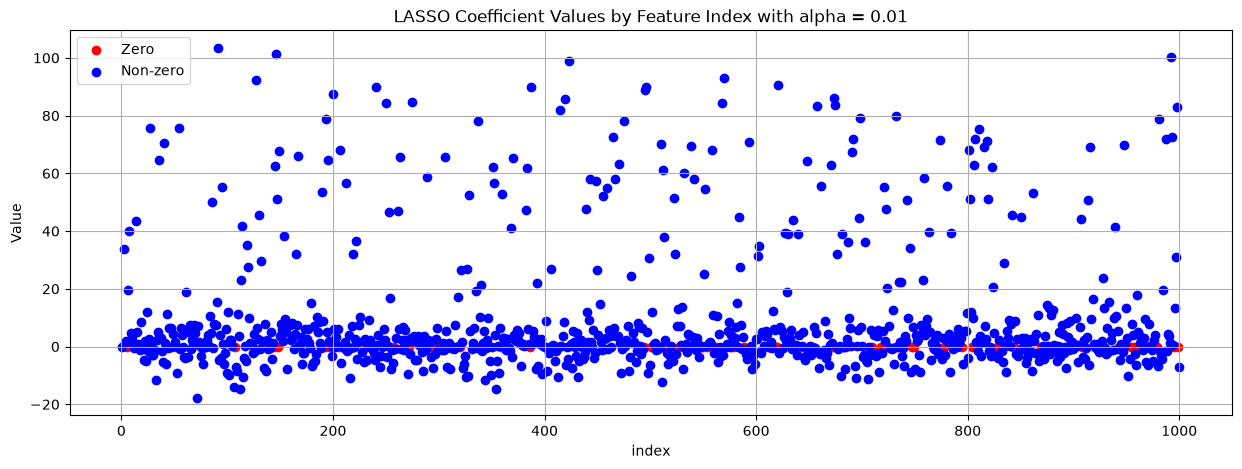

Metrics for i = 0.1:
MAE: 2.76
MSE: 12.50
RMSE: 3.54
R² Score: 1.00
Number of non zero coefs: 314
Max coef magnitude: 100.4940
Mean coef magnitude: 9.4759


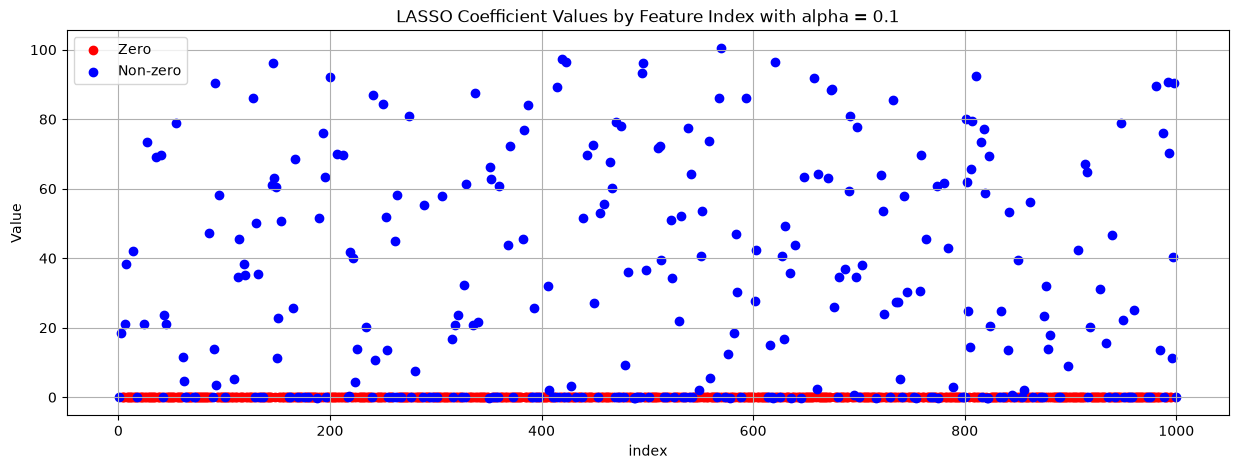

Metrics for i = 1.0:
MAE: 22.69
MSE: 833.82
RMSE: 28.88
R² Score: 1.00
Number of non zero coefs: 270
Max coef magnitude: 99.0944
Mean coef magnitude: 9.2253


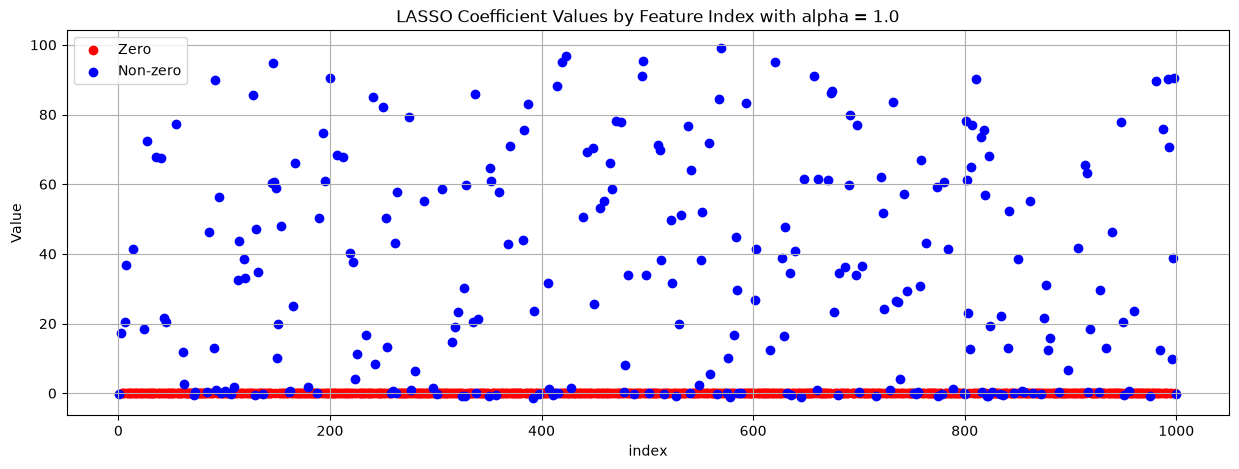

Metrics for i = 10.0:
MAE: 183.25
MSE: 53095.65
RMSE: 230.42
R² Score: 0.92
Number of non zero coefs: 219
Max coef magnitude: 93.2360
Mean coef magnitude: 7.1372


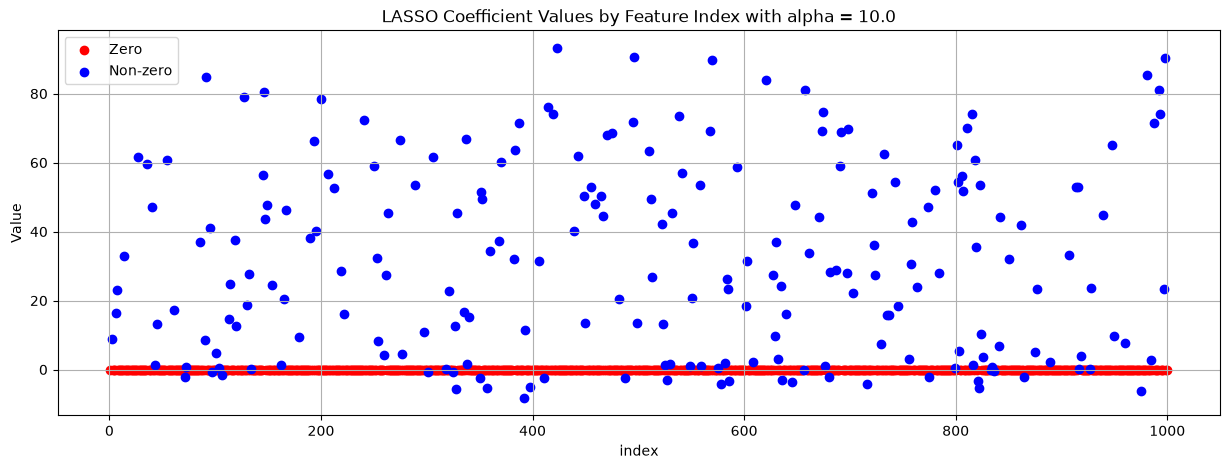

Metrics for i = 100.0:
MAE: 651.48
MSE: 665709.82
RMSE: 815.91
R² Score: 0.03
Number of non zero coefs: 11
Max coef magnitude: 44.7801
Mean coef magnitude: 0.2406


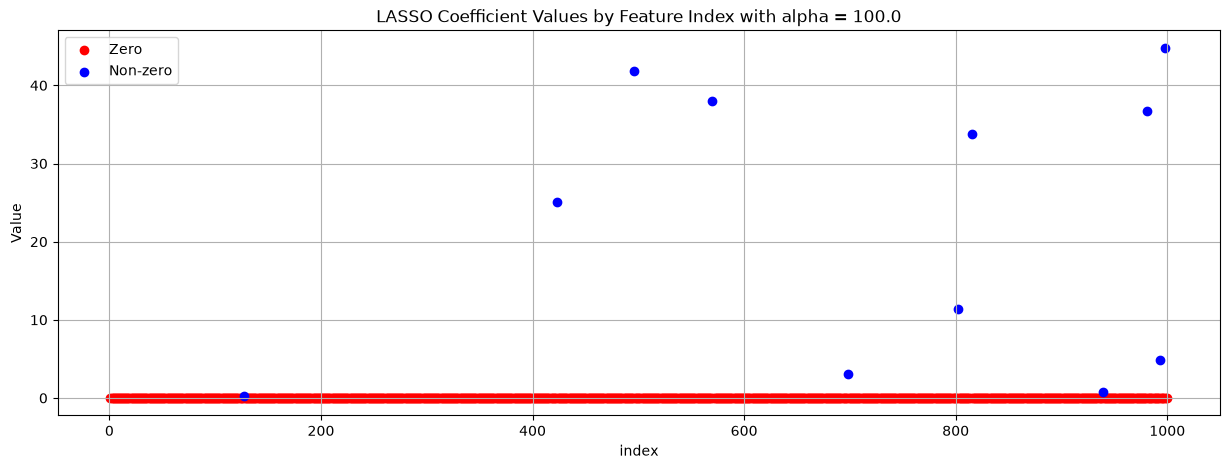

In [5]:
LASSO_models = run_lasso(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)

### Best alpha for LASSO

MAE: 8.69
MSE: 123.41
RMSE: 11.11
R² Score: 1.00
Number of non zero coefs: 281
Max coef magnitude: 100.0541
Mean coef magnitude: 9.3995


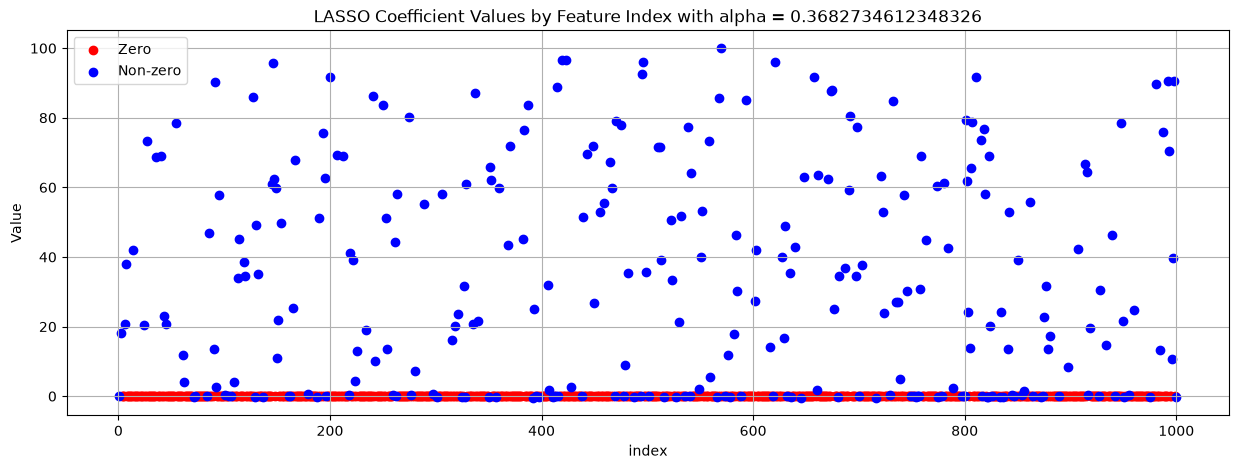

In [6]:
LASSOCV_model = run_lasso_cv(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)

## 4. Ridge

Metrics for i = 0.001:
MAE: 267.14
MSE: 113063.15
RMSE: 336.25
R² Score: 0.83
Number of non zero coefs: 1000
Max coef magnitude: 101.4783
Mean coef magnitude: 13.7408


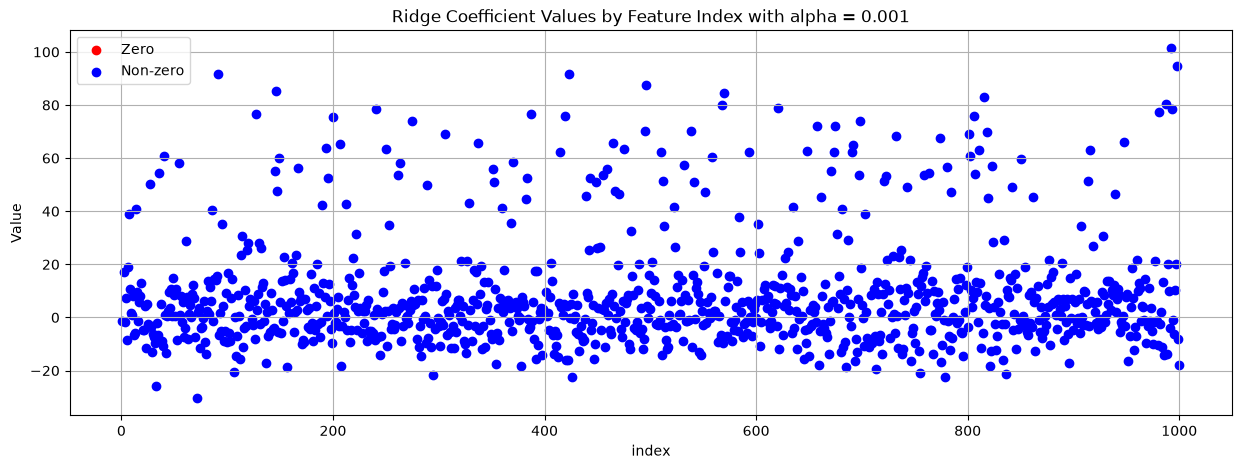

Metrics for i = 0.01:
MAE: 267.14
MSE: 113059.37
RMSE: 336.24
R² Score: 0.83
Number of non zero coefs: 1000
Max coef magnitude: 101.4733
Mean coef magnitude: 13.7402


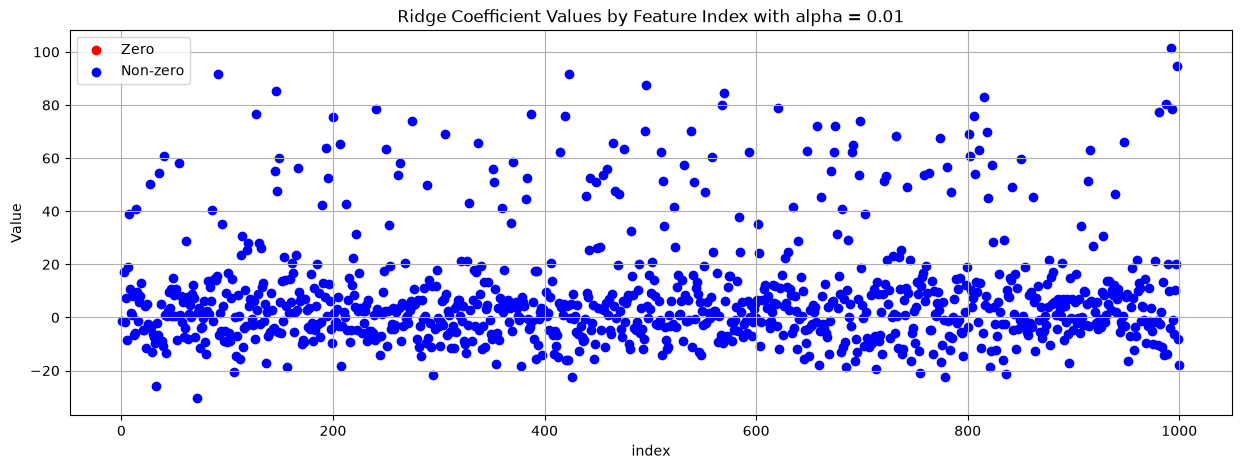

Metrics for i = 0.1:
MAE: 267.08
MSE: 113022.48
RMSE: 336.19
R² Score: 0.83
Number of non zero coefs: 1000
Max coef magnitude: 101.4225
Mean coef magnitude: 13.7335


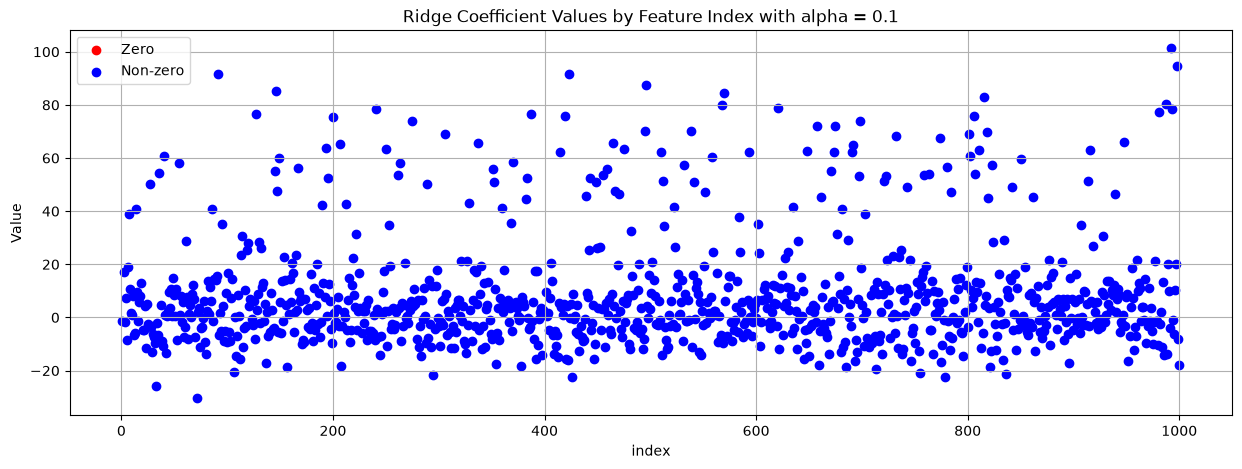

Metrics for i = 1.0:
MAE: 266.66
MSE: 112731.75
RMSE: 335.76
R² Score: 0.84
Number of non zero coefs: 1000
Max coef magnitude: 100.9243
Mean coef magnitude: 13.6687


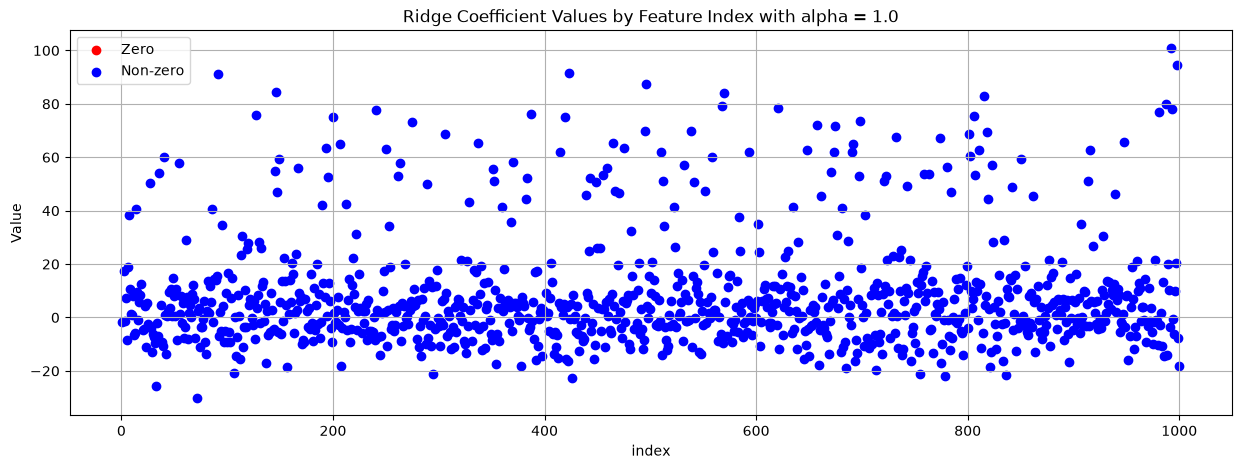

Metrics for i = 10.0:
MAE: 267.92
MSE: 113994.18
RMSE: 337.63
R² Score: 0.83
Number of non zero coefs: 1000
Max coef magnitude: 96.7448
Mean coef magnitude: 13.2091


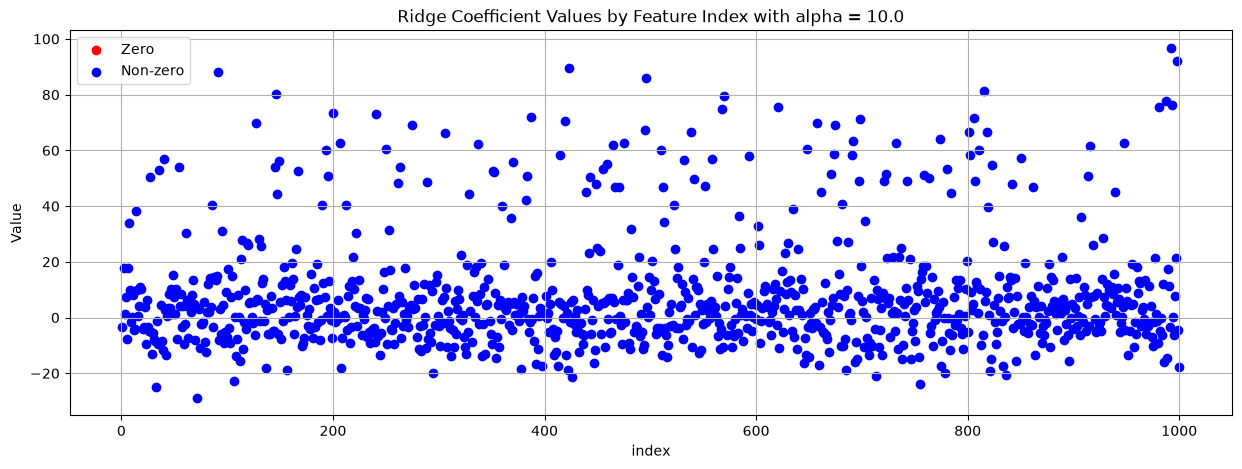

Metrics for i = 100.0:
MAE: 316.59
MSE: 155059.07
RMSE: 393.78
R² Score: 0.77
Number of non zero coefs: 1000
Max coef magnitude: 80.2784
Mean coef magnitude: 11.6541


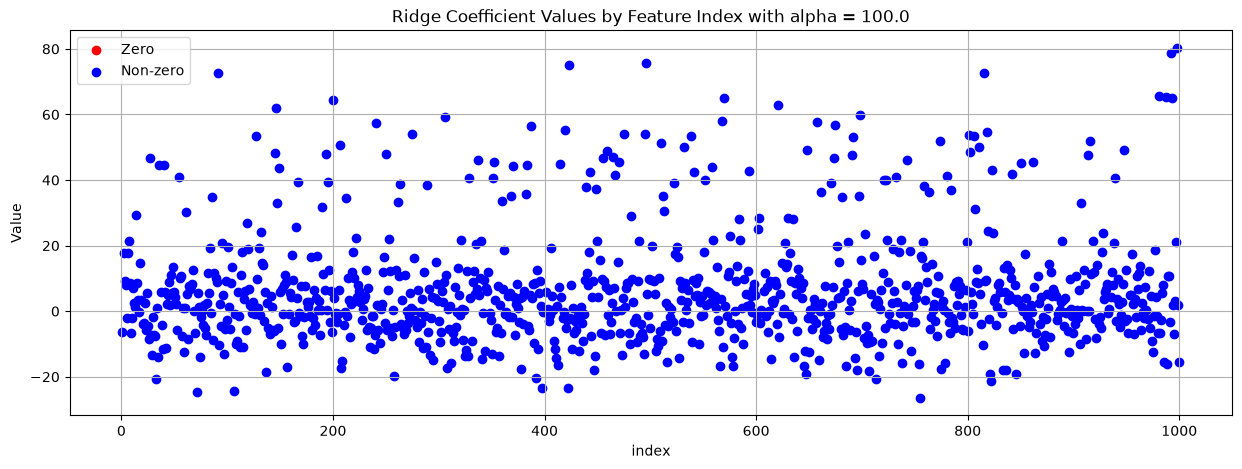

In [7]:
Ridge_models = run_ridge(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)

### Ridge Best Alpha

MAE: 266.66
MSE: 112731.75
RMSE: 335.76
R² Score: 0.84
Number of non zero coefs: 1000
Max coef magnitude: 100.9243
Mean coef magnitude: 13.6687


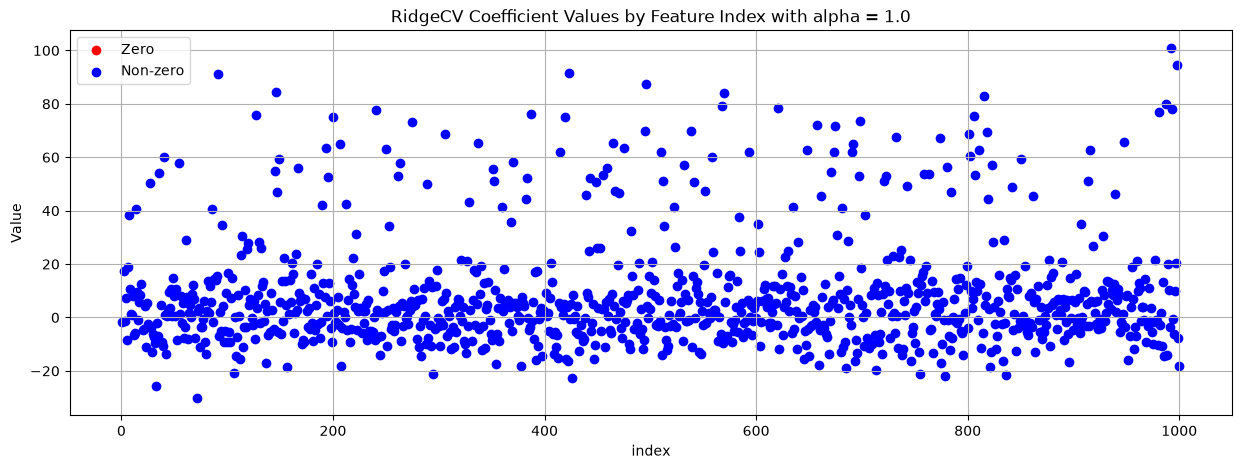

In [8]:
RidgeCV_model = run_ridge_cv(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)

## 5. Elastic Net

Metrics for i = 0.001:
MAE: 251.31
MSE: 102384.72
RMSE: 319.98
R² Score: 0.85
Number of non zero coefs: 1000
Max coef magnitude: 102.3431
Mean coef magnitude: 14.0599


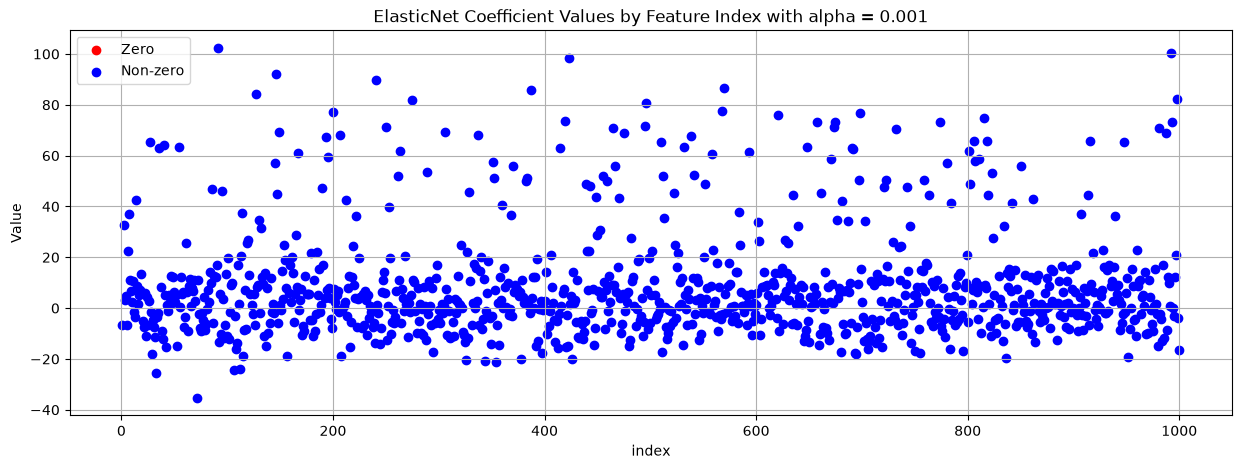

Metrics for i = 0.01:
MAE: 253.25
MSE: 102159.86
RMSE: 319.62
R² Score: 0.85
Number of non zero coefs: 989
Max coef magnitude: 99.1869
Mean coef magnitude: 13.1901


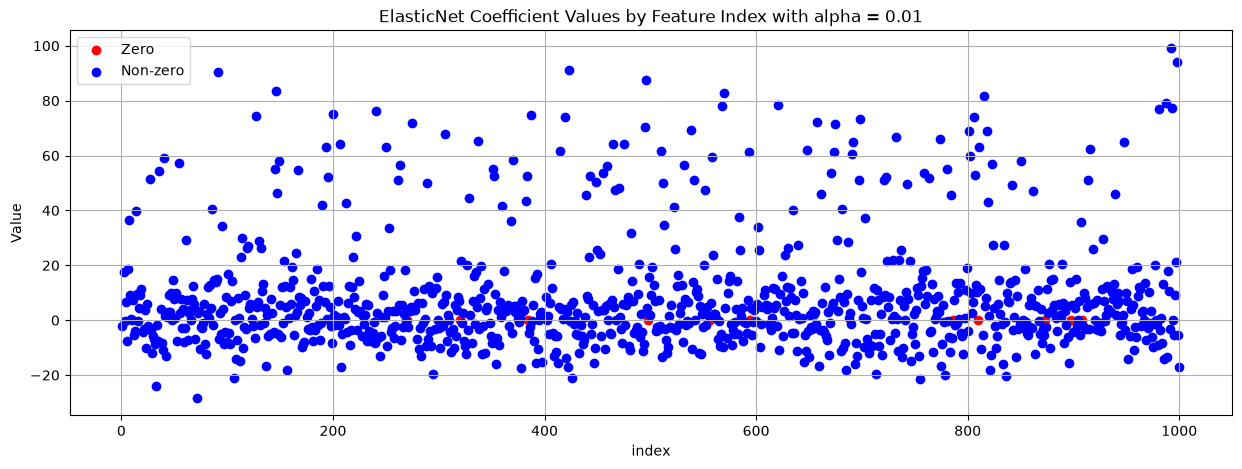

Metrics for i = 0.1:
MAE: 275.82
MSE: 119428.56
RMSE: 345.58
R² Score: 0.83
Number of non zero coefs: 976
Max coef magnitude: 87.9641
Mean coef magnitude: 12.1591


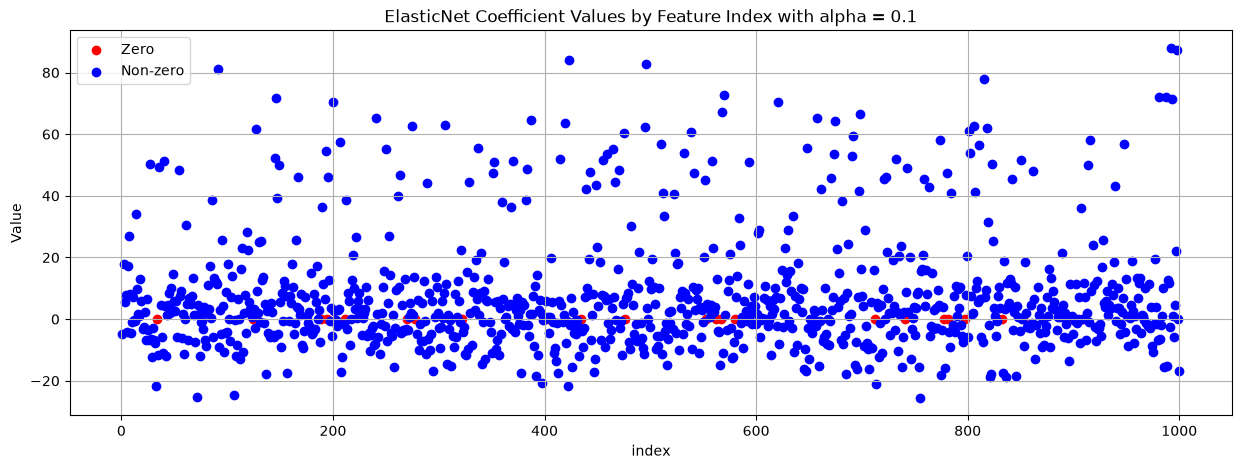

Metrics for i = 1.0:
MAE: 397.43
MSE: 241949.39
RMSE: 491.88
R² Score: 0.65
Number of non zero coefs: 949
Max coef magnitude: 62.7798
Mean coef magnitude: 9.0738


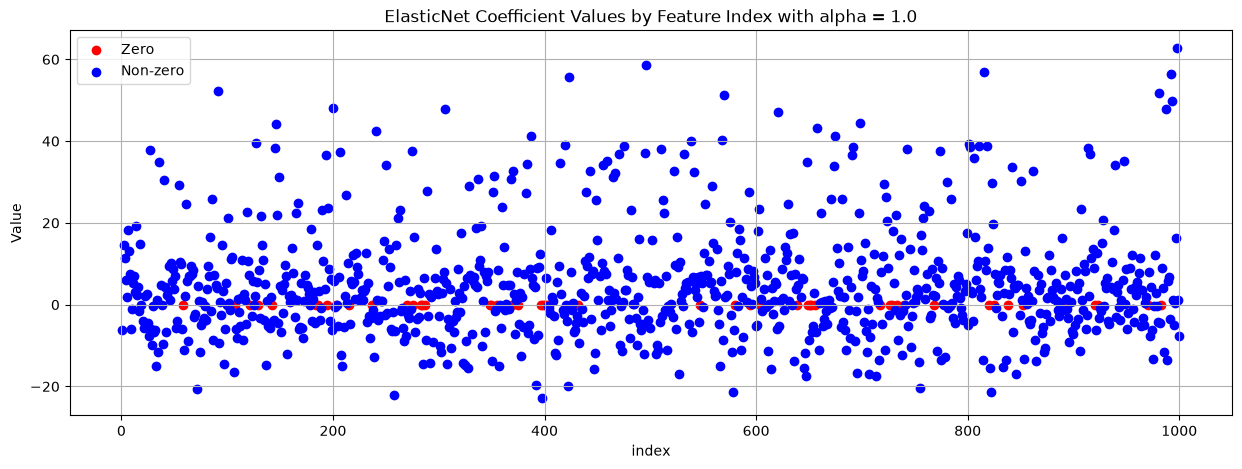

Metrics for i = 10.0:
MAE: 583.70
MSE: 531290.84
RMSE: 728.90
R² Score: 0.22
Number of non zero coefs: 838
Max coef magnitude: 20.2202
Mean coef magnitude: 2.9007


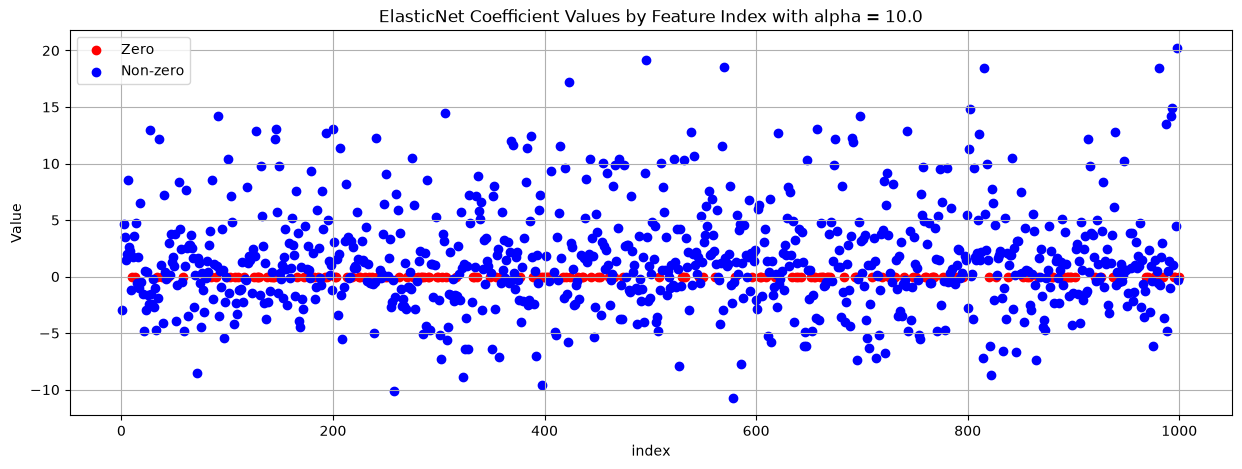

Metrics for i = 100.0:
MAE: 667.94
MSE: 690201.57
RMSE: 830.78
R² Score: -0.01
Number of non zero coefs: 156
Max coef magnitude: 1.9190
Mean coef magnitude: 0.0736


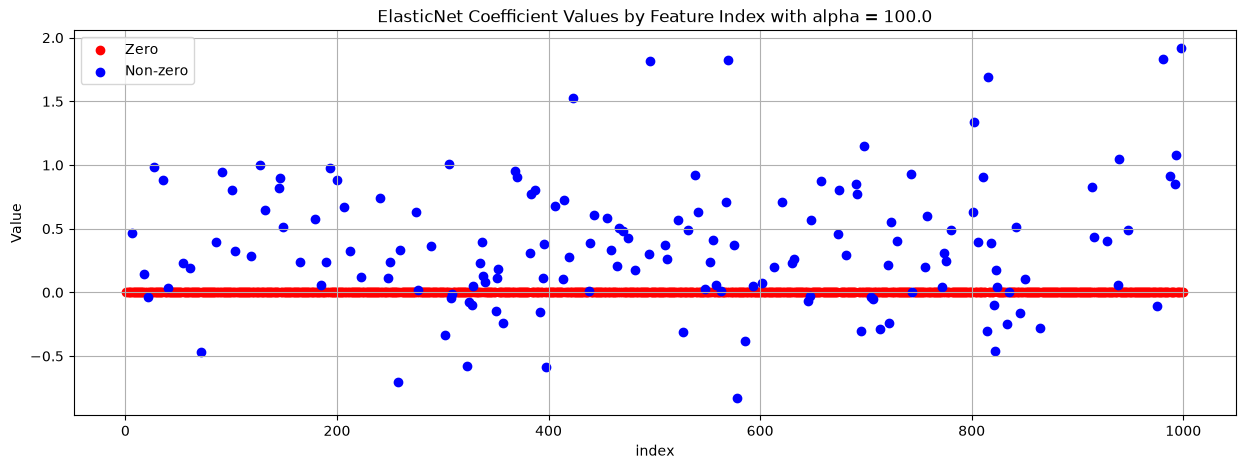

In [9]:
ElasticNet_alpha_models = run_elasticnet_alpha(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)

Metrics for i = 0.0:
MAE: 456.79
MSE: 318510.12
RMSE: 564.37
R² Score: 0.53
Number of non zero coefs: 1000
Max coef magnitude: 49.5136
Mean coef magnitude: 7.8311


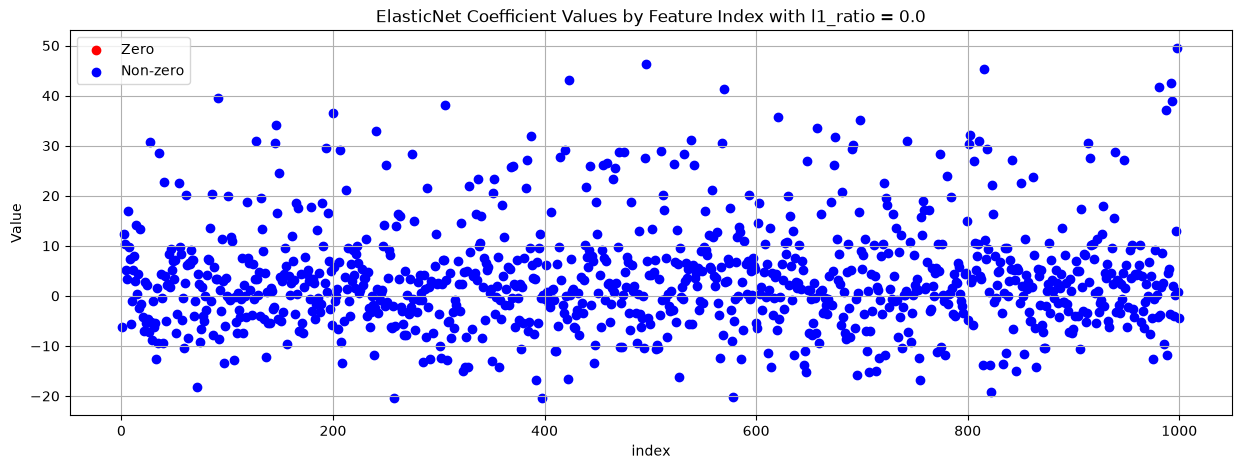

Metrics for i = 0.25:
MAE: 432.13
MSE: 285338.52
RMSE: 534.17
R² Score: 0.58
Number of non zero coefs: 979
Max coef magnitude: 55.1141
Mean coef magnitude: 8.3970


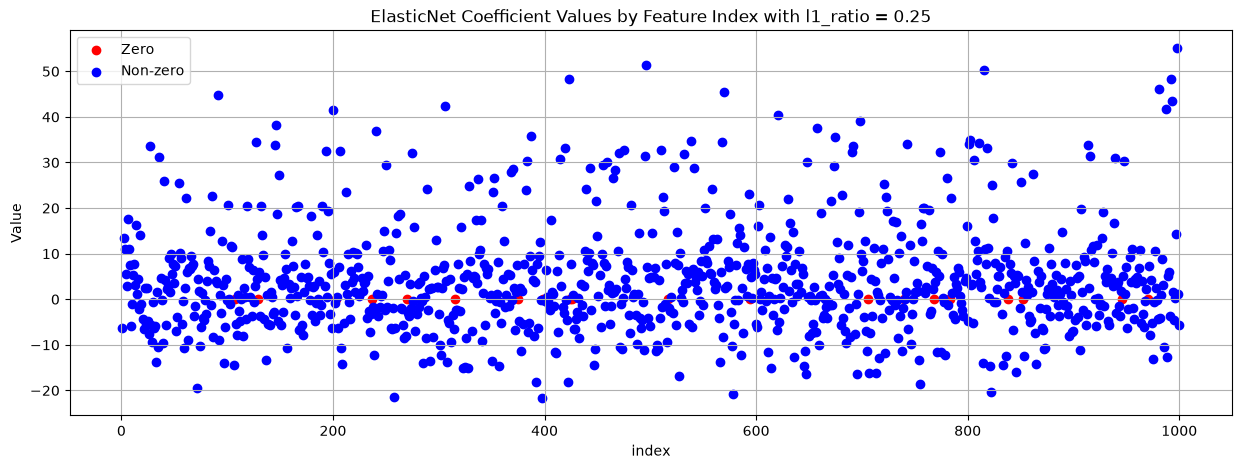

Metrics for i = 0.5:
MAE: 397.43
MSE: 241949.39
RMSE: 491.88
R² Score: 0.65
Number of non zero coefs: 949
Max coef magnitude: 62.7798
Mean coef magnitude: 9.0738


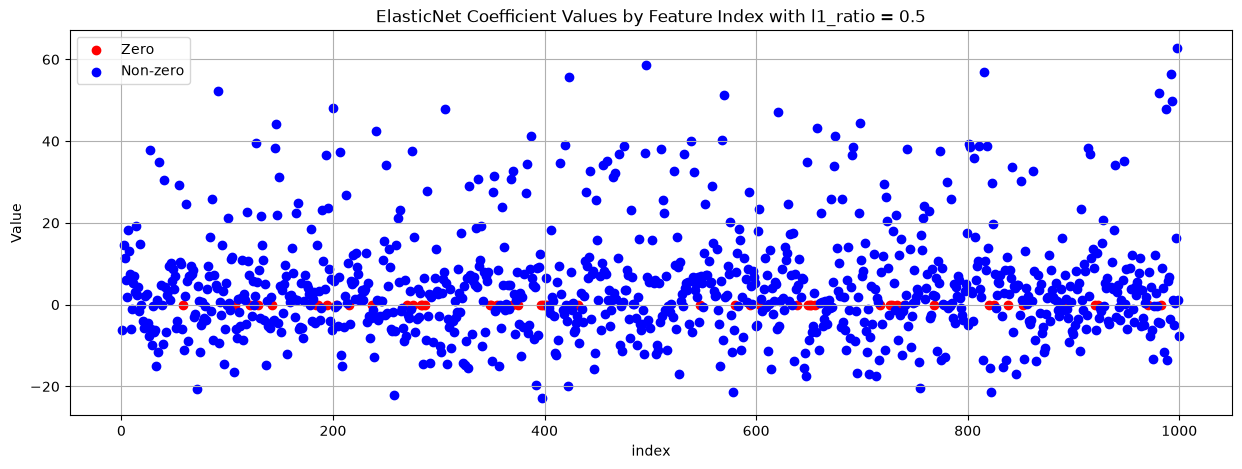

Metrics for i = 0.75:
MAE: 338.93
MSE: 176197.96
RMSE: 419.76
R² Score: 0.74
Number of non zero coefs: 890
Max coef magnitude: 74.2827
Mean coef magnitude: 9.8041


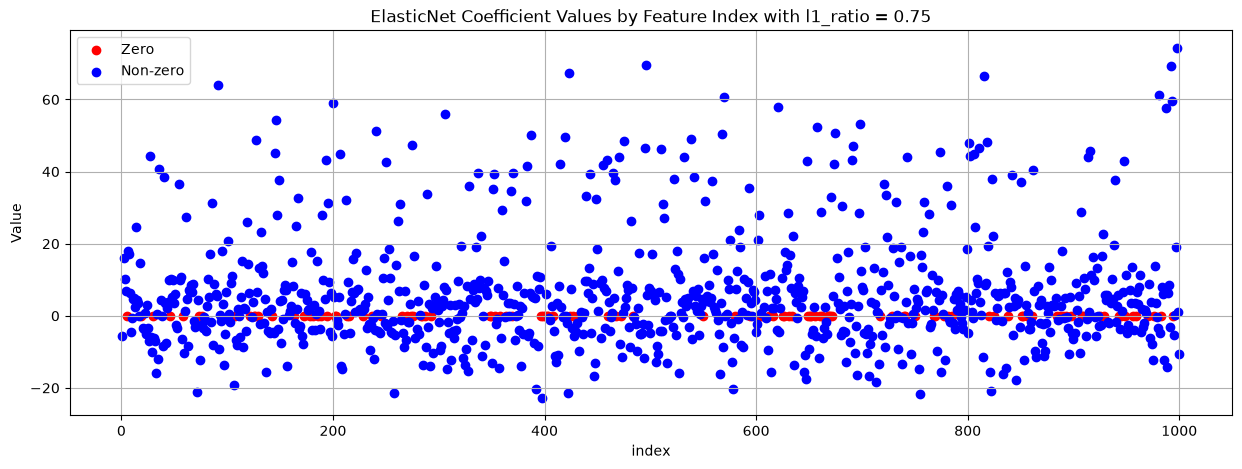

Metrics for i = 1.0:
MAE: 22.69
MSE: 833.82
RMSE: 28.88
R² Score: 1.00
Number of non zero coefs: 270
Max coef magnitude: 99.0944
Mean coef magnitude: 9.2253


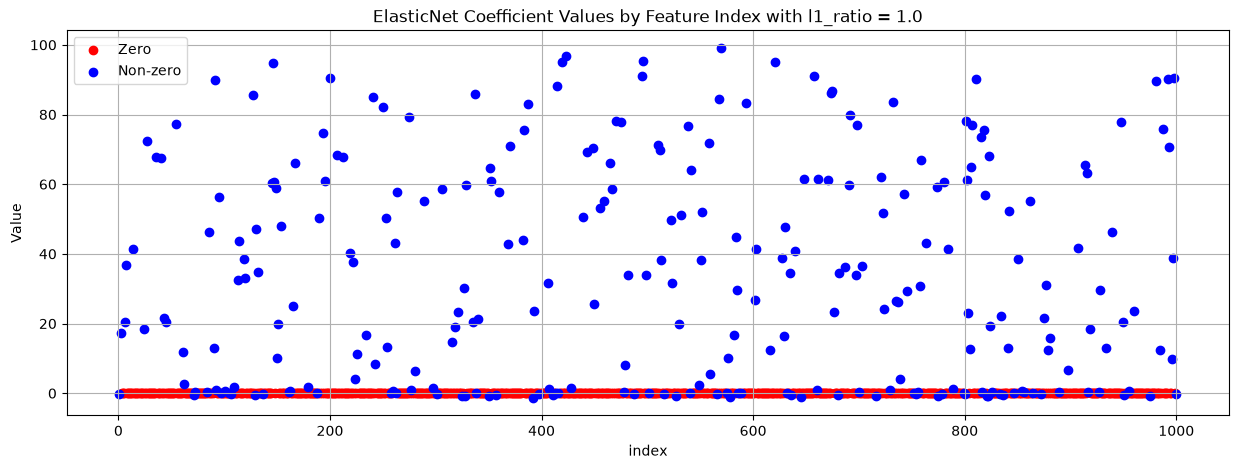

In [10]:
ElasticNet_l1_models = run_elasticnet_l1ratio(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)

### Best alpha and l1 ratio for ElasticNet

MAE: 8.69
MSE: 123.41
RMSE: 11.11
R² Score: 1.00
Number of non zero coefs: 281
Max coef magnitude: 100.0541
Mean coef magnitude: 9.3995


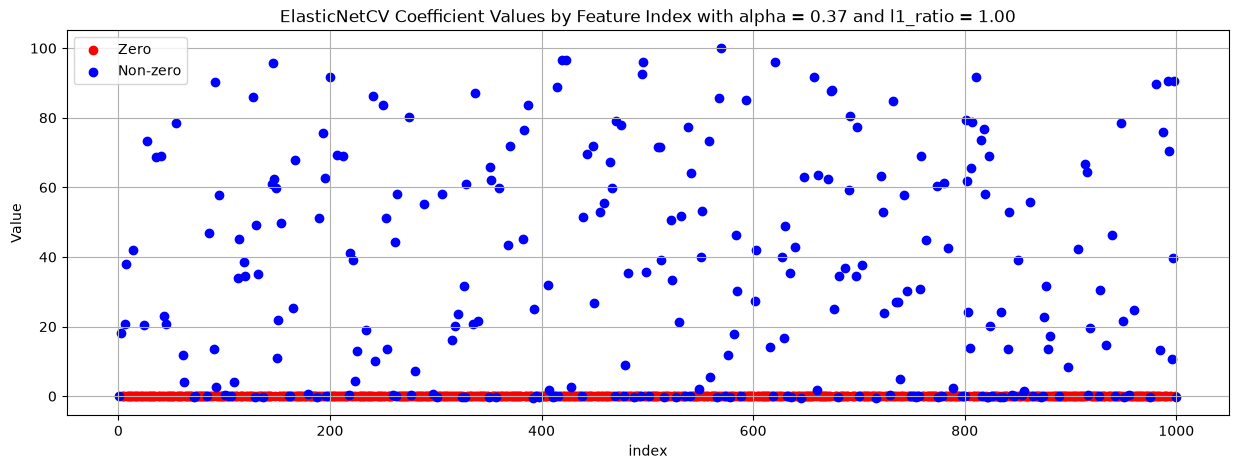

In [11]:
ElasticNet_model = run_elasticnet_cv(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)